# Transfer Learning para Visión por Computador
Este notebook muestra cómo usar un modelo preentrenado (MobileNetV2) para clasificar imágenes personalizadas mediante transferencia de aprendizaje con Keras.

## ¿Qué es transfer learning?
El *transfer learning* consiste en reutilizar un modelo ya entrenado en un problema grande para adaptarlo a una tarea nueva. En visión por computador es especialmente útil porque entrenar una red profunda desde cero suele requerir mucho tiempo, muchos datos y bastante capacidad de cálculo.

Más adelante lo veremos con más detalle, pero de momento quédate con esta idea: si quieres hacer algo con imágenes, usar un modelo preentrenado suele ser una muy buena opción para avanzar más rápido.

In [12]:
# Librerías necesarias
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.io import loadmat
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("Directorio actual:", os.getcwd())

Directorio actual: /home/jmsa/IESRafaelAlberti/RafaelAlberti25_26/Modulos/PIA/UD4/04-modelado-avanzado


## Preparación del entorno y datos
- Usa un conjunto de imágenes en carpetas por clase: `dataset/train/clase1`, `dataset/train/clase2`, etc.

Clases: 102
Train: 1020 | Val: 1020 | Test: 6149


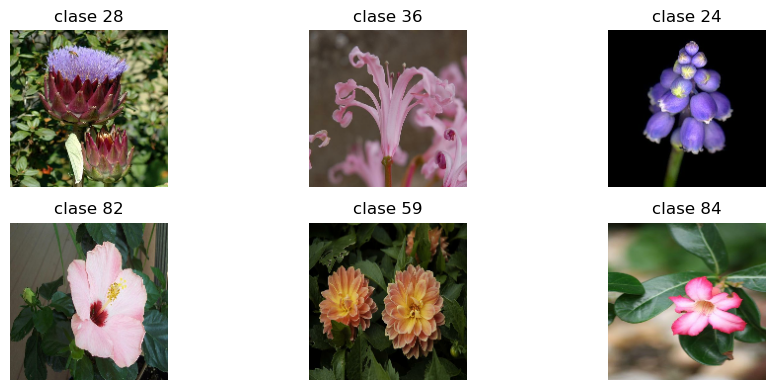

In [13]:
# Carga de Oxford Flowers 102 desde JPG + etiquetas/splits en .mat
img_size = (160, 160)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

data_dir = Path("vision/data/oxford_flowers102")
jpg_dir = data_dir / "jpg"

# imagelabels.mat guarda las clases de cada imagen (1..102)
labels = loadmat(data_dir / "imagelabels.mat")["labels"].squeeze().astype("int32") - 1

# setid.mat trae los índices oficiales de train/valid/test
setid = loadmat(data_dir / "setid.mat")
train_ids = setid["trnid"].squeeze()
val_ids = setid["valid"].squeeze()
test_ids = setid["tstid"].squeeze()

num_classes = int(labels.max() + 1)
print(f"Clases: {num_classes}")
print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

def ids_to_paths(ids):
    return [str(jpg_dir / f"image_{image_id:05d}.jpg") for image_id in ids]

def ids_to_labels(ids):
    return labels[ids - 1]

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = preprocess_input(image)
    return image, label

def make_dataset(ids, training=False):
    paths = ids_to_paths(ids)
    y = ids_to_labels(ids)
    ds = tf.data.Dataset.from_tensor_slices((paths, y))
    if training:
        ds = ds.shuffle(len(ids), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_ids, training=True)
val_ds = make_dataset(val_ids)
test_ds = make_dataset(test_ids)

# Vista rápida de algunas imágenes con su etiqueta numérica
sample_images, sample_labels = next(iter(train_ds))
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = (sample_images[i].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"clase {int(sample_labels[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Carga del modelo MobileNetV2 preentrenado (sin la capa final)

In [14]:
# Base preentrenada
base_model = MobileNetV2(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

# Modelo completo
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 102)            │        13,158 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,110 (9.29 MB)

 Trainable params: 177,126 (691.90 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Entrenamiento del modelo

In [15]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - accuracy: 0.0480 - loss: 4.5697 - val_accuracy: 0.1892 - val_loss: 4.0759
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.2520 - loss: 3.4933 - val_accuracy: 0.4216 - val_loss: 2.9923
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.4490 - loss: 2.4084 - val_accuracy: 0.5843 - val_loss: 2.1256
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.6529 - loss: 1.5971 - val_accuracy: 0.6775 - val_loss: 1.6410
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.7510 - loss: 1.1143 - val_accuracy: 0.7196 - val_loss: 1.3759
Test accuracy: 0.6718


## Visualización de métricas

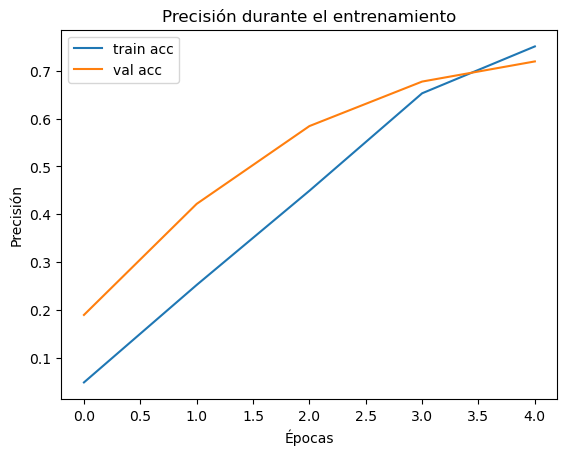

In [16]:
# Curvas de pérdida y precisión
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento')
plt.show()

## Actividad guiada

In [ ]:
from IPython.display import Markdown
Markdown('''
**Actividad:**

1. Usa otro modelo preentrenado como `ResNet50` o `EfficientNet`.
2. Cambia el tamaño de las imágenes o el número de épocas.
3. Añade técnicas de data augmentation.
4. Prueba a descongelar algunas capas del modelo base y hacer fine-tuning.
''')

## Nota sobre formatos de dataset
En ejemplos sencillos es habitual organizar las imágenes en subdirectorios por clase, porque herramientas como `flow_from_directory` pueden inferir automáticamente las etiquetas. Sin embargo, en problemas más realistas esto no siempre es la mejor opción: cuando hay muchas clases, particiones oficiales o metadatos adicionales, suele ser más práctico separar las imágenes de las etiquetas y de los *splits*.

En este dataset aparecen dos formas comunes de empaquetar datos:

- `jpg` + `.mat`: las imágenes están en una carpeta común y los ficheros `.mat` guardan información auxiliar. En `imagelabels.mat` están las etiquetas de cada imagen y en `setid.mat` están los índices oficiales de entrenamiento, validación y prueba. Es una forma muy usada en datasets académicos publicados originalmente para Matlab.
- `.npz` + `.json`: un fichero `.npz` es un contenedor de NumPy que guarda varios arrays en un solo archivo, por ejemplo `x_train`, `y_train`, `x_test` y `y_test`. Suele ir acompañado de un `.json` con metadatos legibles, como el tamaño de imagen, el número de clases o una breve descripción del contenido.

La idea importante es esta: en datasets pequeños puede bastar con una carpeta por clase, pero en conjuntos más grandes o más formales es muy normal encontrar las imágenes por un lado y las etiquetas, particiones y metadatos en ficheros separados.